In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## prefix caching enabled, no chunk prefill
# input_file='workload/prefix-sharing-workload/prefixsharingworkload-p1024_s128_rps5-p2048_s128_rps5-p4096_s128_rps5-maxtoken4096.output.csv'
# input_file='workload/prefix-sharing-workload/prefixsharingworkload-p1024_s128_rps5-p2048_s128_rps5-p4096_s128_rps5-maxtoken100.output.csv'

## prefix caching enabled, chunk prefill enabled
# input_file='./workload/prefix-sharing-workload/prefixsharingworkload-p1024_s128_rps5-maxtoken100.output.csv'
input_file='./workload/prefix-sharing-workload/prefixsharingworkload-p1024_s128_rps5-p2048_s128_rps5-p4096_s128_rps5-maxtokens4096-prefixcaching-chunkprefill.output.csv'

df = pd.read_csv(input_file)


# # if there is 'prompt_text' or 'output_text' column, drop them
# if 'prompt_text' in df.columns:
#     df = df.drop(columns=['prompt_text'])
#     print(f"Dropping 'prompt_text' column from the DataFrame.")
# if 'output_text' in df.columns:
#     df = df.drop(columns=['output_text'])
#     print(f"Dropping 'output_text' column from the DataFrame.")


failed_requests = df[df['status'] == 'error']
print(f"Total requests: {len(df)}")
print(f"Failed requests: {len(failed_requests)}")
print(f"Successful requests: {len(df) - len(failed_requests)}")
print(f"Success rate: {100 * (len(df) - len(failed_requests)) / len(df):.2f}%")
df = df[df['status'] == 'success']
df['client_side_start_time'] = df['client_side_start_time'].astype(int)
df['client_side_end_time'] = df['client_side_end_time'].astype(int)
start_time = df['client_side_start_time'].min()
end_time = df['client_side_end_time'].max()
print(f"Experiment duration: {(end_time - start_time)} seconds")
df['client_side_start_time'] = (df['client_side_start_time'] - start_time)
df['client_side_end_time'] = (df['client_side_end_time'] - start_time)


df['kv_cache_hit_ratio'] = df['kv_cache_hit_ratio'].apply(lambda x: eval(x))
df['selected_pod_kv_cache_hit_ratio'] = df.apply(lambda row: row['kv_cache_hit_ratio'][row['selected_pod_name']], axis=1)

df['vllm_gpu_kv_cache_usage'] = df['vllm_gpu_kv_cache_usage'].apply(lambda x: eval(x))
df['selected_pod_vllm_gpu_kv_cache_usage'] = df.apply(lambda row: row['vllm_gpu_kv_cache_usage'][row['selected_pod_name']], axis=1)

df['vllm_cpu_kv_cache_usage'] = df['vllm_cpu_kv_cache_usage'].apply(lambda x: eval(x))
df['selected_pod_vllm_cpu_kv_cache_usage'] = df.apply(lambda row: row['vllm_cpu_kv_cache_usage'][row['selected_pod_name']], axis=1)

df['total_num_inflight_requests'] = df['num_inflight_requests'].apply(lambda x: sum(eval(x).values()))
df['num_inflight_requests'] = df['num_inflight_requests'].apply(lambda x: eval(x))
df['selected_pod_num_inflight_requests'] = df.apply(lambda row: row['num_inflight_requests'][row['selected_pod_name']], axis=1)

df['total_vllm_num_running_requests'] = df['vllm_num_running_requests'].apply(lambda x: sum(eval(x).values()))
df['vllm_num_running_requests'] = df['vllm_num_running_requests'].apply(lambda x: eval(x))
df['selected_pod_num_running_requests'] = df.apply(lambda row: row['vllm_num_running_requests'][row
['selected_pod_name']], axis=1)

df['total_vllm_num_waiting_requests'] = df['vllm_num_waiting_requests'].apply(lambda x: sum(eval(x).values()))
df['vllm_num_waiting_requests'] = df['vllm_num_waiting_requests'].apply(lambda x: eval(x))
df['selected_pod_num_waiting_requests'] = df.apply(lambda row: row['vllm_num_waiting_requests'][row['selected_pod_name']], axis=1)

## vllm concurrent request config


Total requests: 800
Failed requests: 427
Successful requests: 373
Success rate: 46.62%
Experiment duration: 1013 seconds


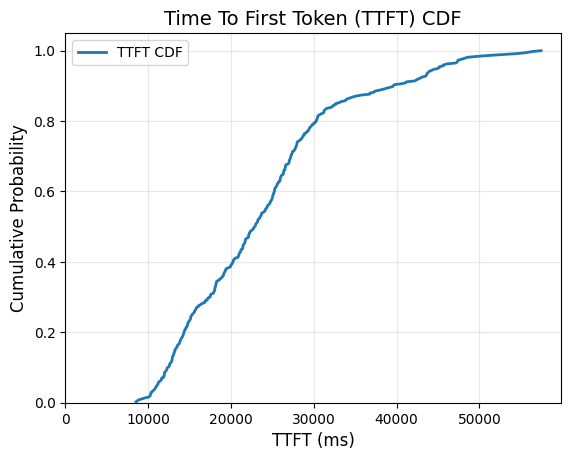

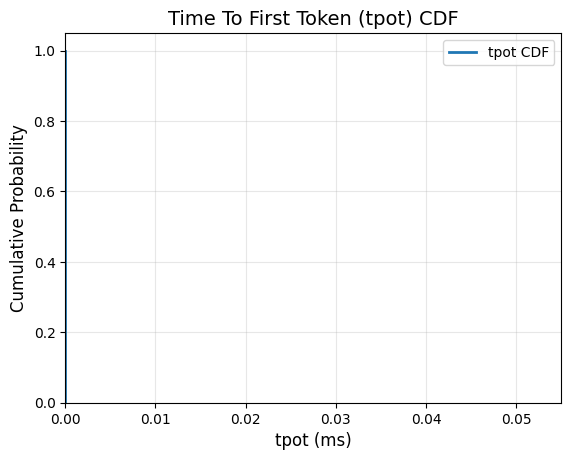

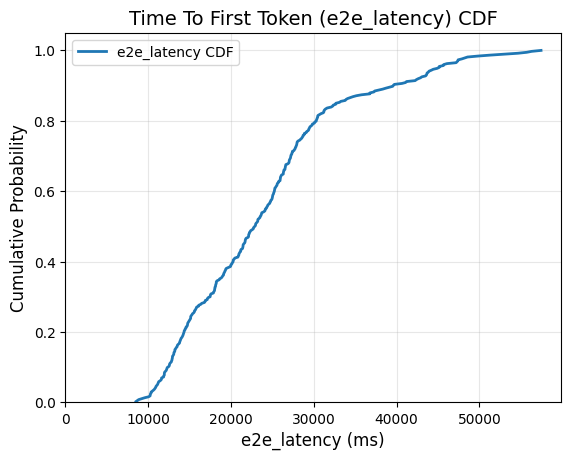

In [13]:
ttft = df['gateway_side_ttft'].astype(int)
ttft_sorted = np.sort(ttft)
y = np.arange(1, len(ttft_sorted) + 1) / len(ttft_sorted)
plt.figure()
plt.plot(ttft_sorted, y, linewidth=2, label='TTFT CDF')
plt.grid(True, alpha=0.3)
plt.xlabel('TTFT (ms)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Time To First Token (TTFT) CDF', fontsize=14)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()

tpot = df['gateway_side_tpot'].astype(int)
tpot_sorted = np.sort(tpot)
y = np.arange(1, len(tpot_sorted) + 1) / len(tpot_sorted)
plt.figure()
plt.plot(tpot_sorted, y, linewidth=2, label='tpot CDF')
plt.grid(True, alpha=0.3)
plt.xlabel('tpot (ms)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Time To First Token (tpot) CDF', fontsize=14)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()

e2e_latency = df['gateway_side_e2e_latency'].astype(int)
e2e_latency_sorted = np.sort(e2e_latency)
y = np.arange(1, len(e2e_latency_sorted) + 1) / len(e2e_latency_sorted)
plt.figure()
plt.plot(e2e_latency_sorted, y, linewidth=2, label='e2e_latency CDF')
plt.grid(True, alpha=0.3)
plt.xlabel('e2e_latency (ms)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Time To First Token (e2e_latency) CDF', fontsize=14)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()

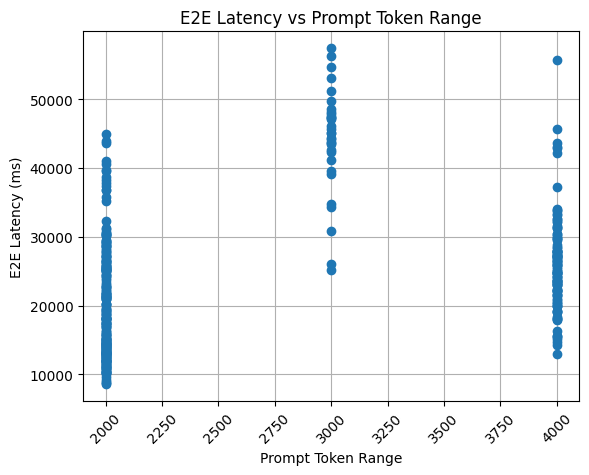

In [ ]:
df['prompt_token_range'] = pd.cut(df['prompt_tokens'], 
                                 bins=[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000], 
                                 labels=[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])
                                #  labels=['0-999', '1000-1999', '2000-2999', '3000-3999', '4000-4999','5000-5999', '6000-6999', '7000-7999', '8000-8999', '9000-9999'])

## Correlation prompt token range and E2E latency
plt.figure()
plt.plot(df['prompt_token_range'], df['gateway_side_e2e_latency'], 'o')
plt.xlabel('Prompt Token Range')
plt.ylabel('E2E Latency (ms)')
plt.title('E2E Latency vs Prompt Token Range')
plt.xticks(rotation=45)
plt.grid(True)

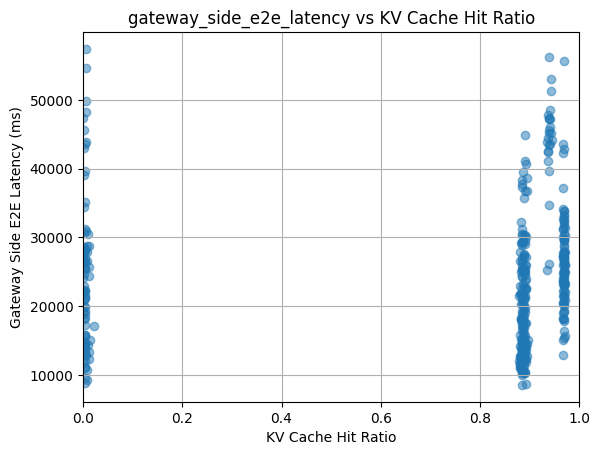

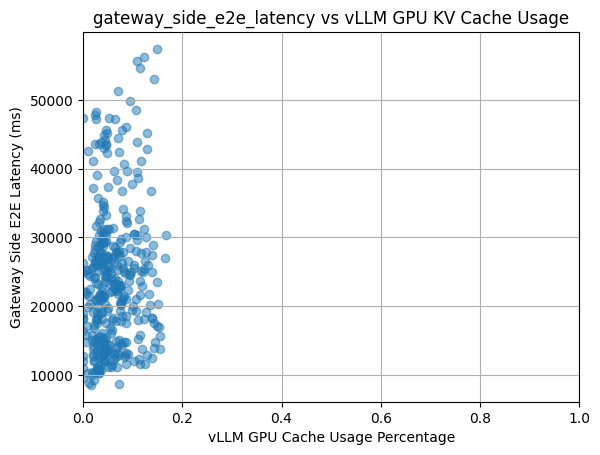

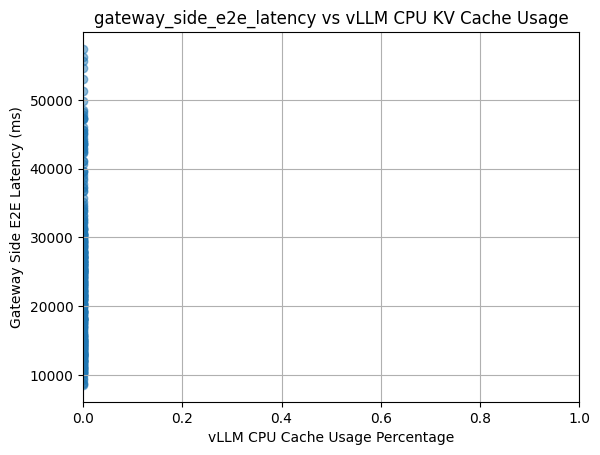

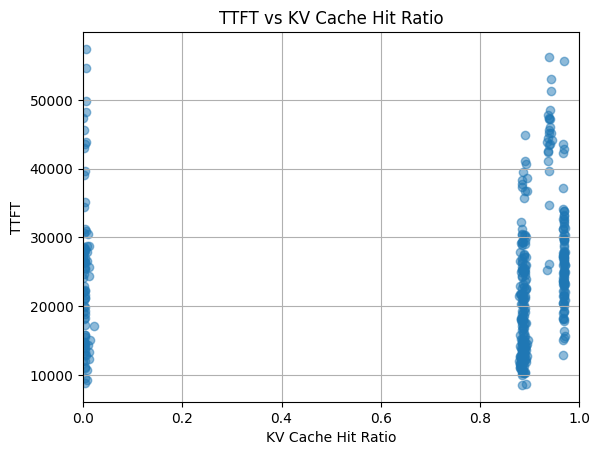

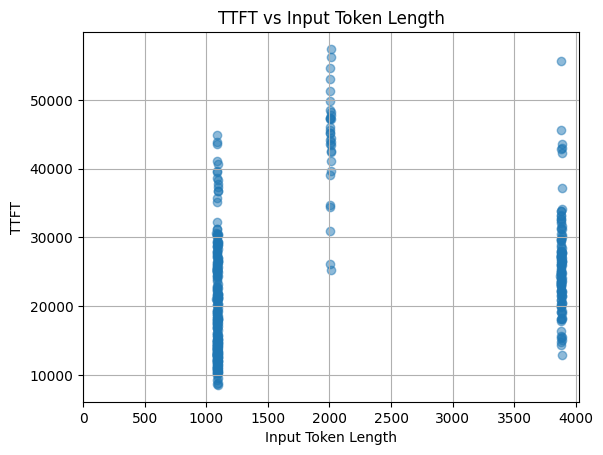

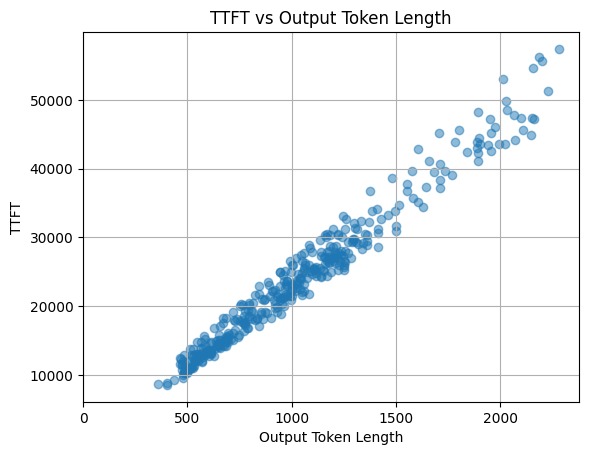

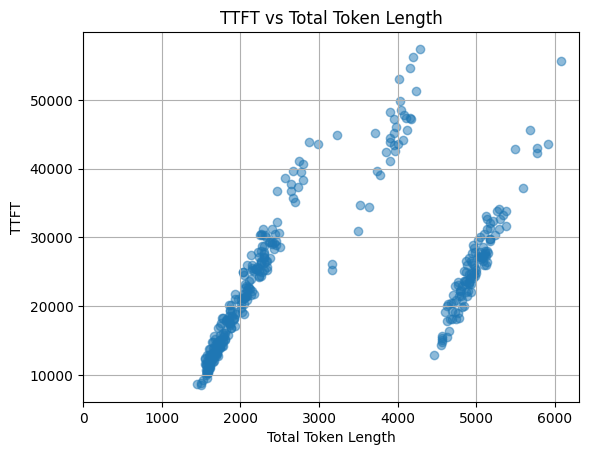

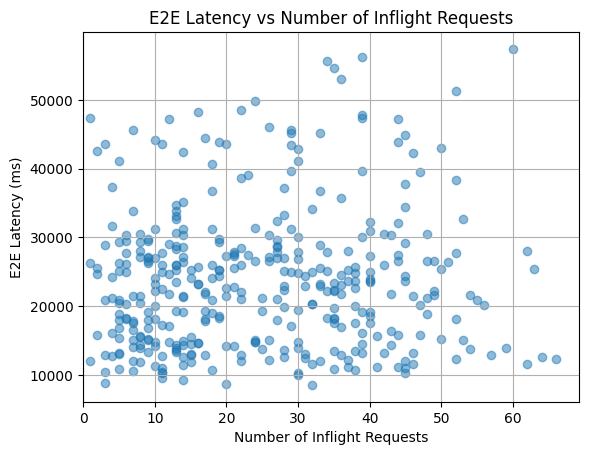

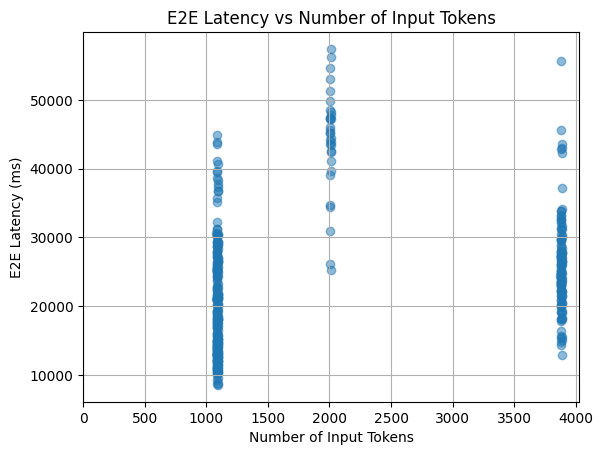

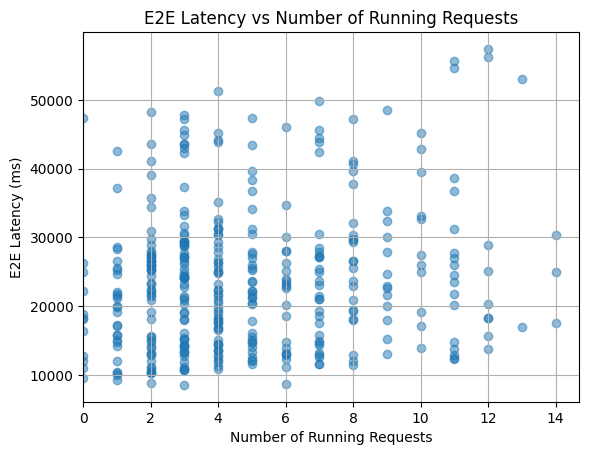

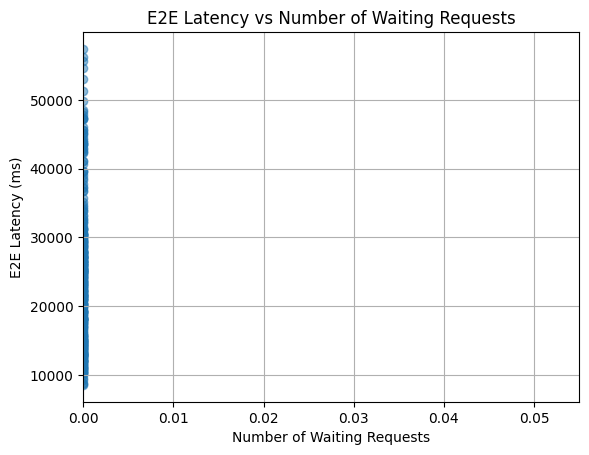

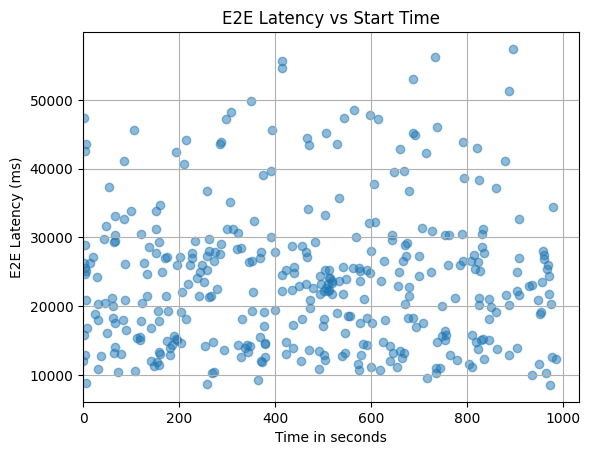

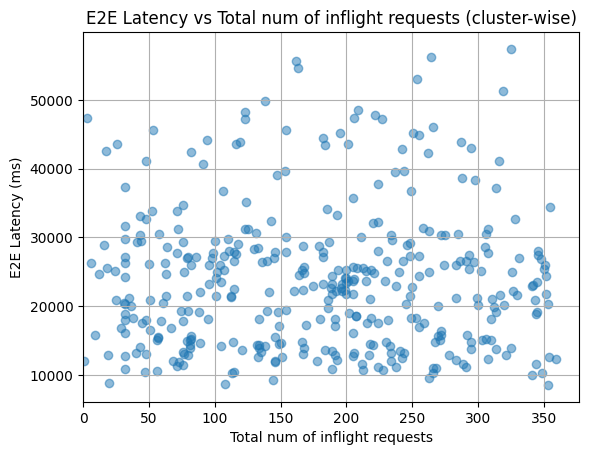

In [19]:
## Correlation between gateway side e2e latency and kv cache hit ratio
plt.figure()
plt.scatter(df['selected_pod_kv_cache_hit_ratio'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('gateway_side_e2e_latency vs KV Cache Hit Ratio')
plt.xlabel('KV Cache Hit Ratio')
plt.ylabel('Gateway Side E2E Latency (ms)')
plt.xlim(0, 1)
plt.grid()

## Correlation between gateway side e2e latency and gpu kv cache usage
plt.figure()
plt.scatter(df['selected_pod_vllm_gpu_kv_cache_usage'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('gateway_side_e2e_latency vs vLLM GPU KV Cache Usage')
plt.xlabel('vLLM GPU Cache Usage Percentage')
plt.xlim(0, 1)
plt.ylabel('Gateway Side E2E Latency (ms)')
plt.grid()

## Correlation between gateway side e2e latency and cpu kv cache usage
plt.figure()
plt.scatter(df['selected_pod_vllm_cpu_kv_cache_usage'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('gateway_side_e2e_latency vs vLLM CPU KV Cache Usage')
plt.xlabel('vLLM CPU Cache Usage Percentage')
plt.xlim(0, 1)
plt.ylabel('Gateway Side E2E Latency (ms)')
plt.grid()

## Correlation between ttft and kv cache hit ratio
plt.figure()
plt.scatter(df['selected_pod_kv_cache_hit_ratio'], df['gateway_side_ttft'], alpha=0.5)
plt.title('TTFT vs KV Cache Hit Ratio')
plt.xlabel('KV Cache Hit Ratio')
plt.ylabel('TTFT')
plt.xlim(0, 1)
plt.grid()

## Correlation between ttft and input token length
plt.figure()
plt.scatter(df['prompt_tokens'], df['gateway_side_ttft'], alpha=0.5)
plt.title('TTFT vs Input Token Length')
plt.xlabel('Input Token Length')
plt.ylabel('TTFT')
plt.xlim(left=0)
plt.grid()

## Correlation between ttft and output token length
plt.figure()
plt.scatter(df['output_tokens'], df['gateway_side_ttft'], alpha=0.5)
plt.title('TTFT vs Output Token Length')
plt.xlabel('Output Token Length')
plt.ylabel('TTFT')
plt.xlim(left=0)
plt.grid()

## Correlation between ttft and total token length
plt.figure()
plt.scatter(df['total_tokens'], df['gateway_side_ttft'], alpha=0.5)
plt.title('TTFT vs Total Token Length')
plt.xlabel('Total Token Length')
plt.ylabel('TTFT')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and num inflight requests
plt.figure()
plt.scatter(df['selected_pod_num_inflight_requests'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Number of Inflight Requests')
plt.xlabel('Number of Inflight Requests')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and num of input tokens
plt.figure()
plt.scatter(df['prompt_tokens'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Number of Input Tokens')
plt.xlabel('Number of Input Tokens')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and num running requests
plt.figure()
plt.scatter(df['selected_pod_num_running_requests'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Number of Running Requests')
plt.xlabel('Number of Running Requests')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and num waiting requests
plt.figure()
plt.scatter(df['selected_pod_num_waiting_requests'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Number of Waiting Requests')
plt.xlabel('Number of Waiting Requests')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and start time
plt.figure()
plt.scatter(df['client_side_start_time'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Start Time')
plt.xlabel('Time in seconds')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()

## Correlation between e2e latency and total inflight requests
plt.figure()
plt.scatter(df['total_num_inflight_requests'], df['gateway_side_e2e_latency'], alpha=0.5)
plt.title('E2E Latency vs Total num of inflight requests (cluster-wise)')
plt.xlabel('Total num of inflight requests')
plt.ylabel('E2E Latency (ms)')
plt.xlim(left=0)
plt.grid()


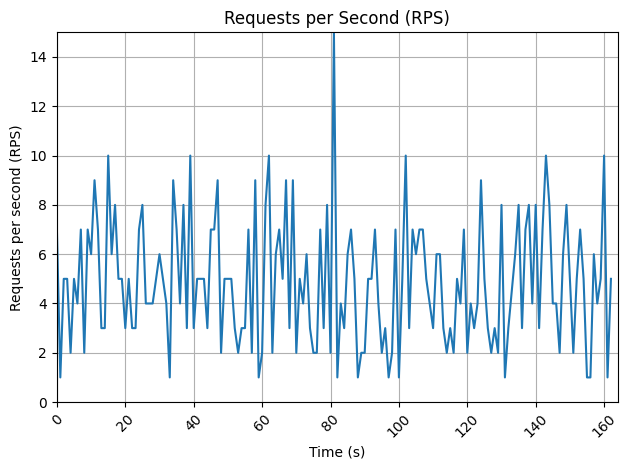

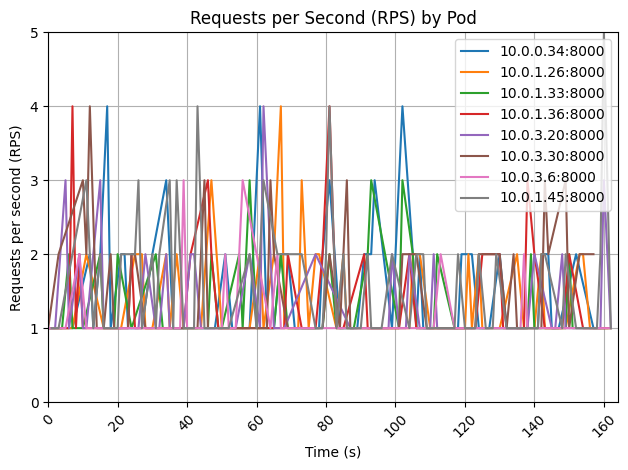

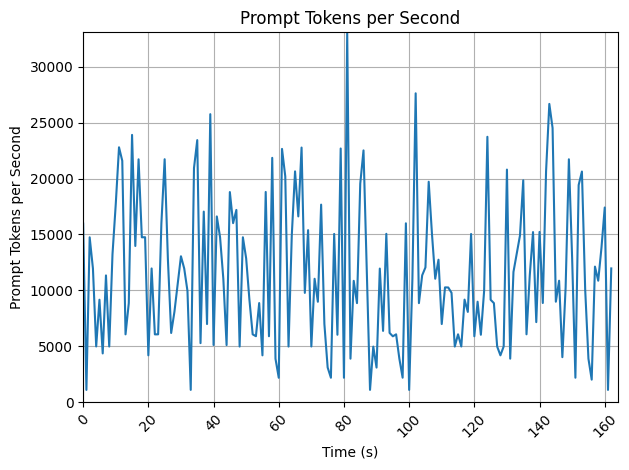

In [9]:
## plot load (rps)
rps = df.groupby('client_side_start_time').size().reset_index(name='count')
plt.figure()
plt.plot(rps['client_side_start_time'], rps['count'])
plt.xlabel('Time (s)')
plt.ylabel('Requests per second (RPS)')
plt.title('Requests per Second (RPS)')
plt.xticks(rotation=45)
plt.xlim(0, end_time - start_time)
plt.ylim(0, rps['count'].max())
plt.grid()
plt.tight_layout()

## plot load for each pod
pod_rps = df.groupby(['client_side_start_time', 'selected_pod_ip']).size().reset_index(name='count')
plt.figure()
for pod_ip in pod_rps['selected_pod_ip'].unique():
    pod_data = pod_rps[pod_rps['selected_pod_ip'] == pod_ip]
    plt.plot(pod_data['client_side_start_time'], pod_data['count'], label=pod_ip)
plt.xlabel('Time (s)')
plt.ylabel('Requests per second (RPS)')
plt.title('Requests per Second (RPS) by Pod')
plt.xticks(rotation=45)
plt.xlim(0, end_time - start_time)
plt.ylim(0, pod_rps['count'].max())
plt.legend()
plt.grid()
plt.tight_layout()


## plot load (prompt tokens per second)
prompt_tokens_per_second = df.groupby('client_side_start_time')['prompt_tokens'].sum().reset_index(name='count')
plt.figure()
plt.plot(prompt_tokens_per_second['client_side_start_time'], prompt_tokens_per_second['count'])
plt.xlabel('Time (s)')
plt.ylabel('Prompt Tokens per Second')
plt.title('Prompt Tokens per Second')
plt.xticks(rotation=45)
plt.xlim(0, end_time - start_time)
plt.ylim(0, prompt_tokens_per_second['count'].max())
plt.grid()
plt.tight_layout()

# ## plot output tokens per second
# output_tokens_per_second = df.groupby('client_side_start_time')['output_tokens'].sum().reset_index(name='count')
# plt.figure()
# plt.plot(output_tokens_per_second['client_side_start_time'], output_tokens_per_second['count'])
# plt.xlabel('Time (s)')
# plt.ylabel('Output Tokens per Second')
# plt.title('Output Tokens per Second')
# plt.xticks(rotation=45)
# plt.xlim(0, end_time - start_time)
# plt.ylim(0, output_tokens_per_second['count'].max())
# plt.grid()
# plt.tight_layout()


